In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

## Linear Regression with One Variable 
### Show the plot

In [2]:
datafile = 'data/ex1data1.txt'
cols = np.loadtxt(datafile,delimiter=',',usecols=(0,1),unpack=True)
#Read in comma separated data

#Form the usual "X" matrix and "y" vector
X = np.transpose(np.array(cols[:-1]))
y = np.transpose(np.array(cols[-1:]))
m = y.size
#Insert the usual column of 1's into the "X" matrix
X = np.insert(X,0,1,axis=1)

Text(0.5, 0, 'Population of City in 10,000s')

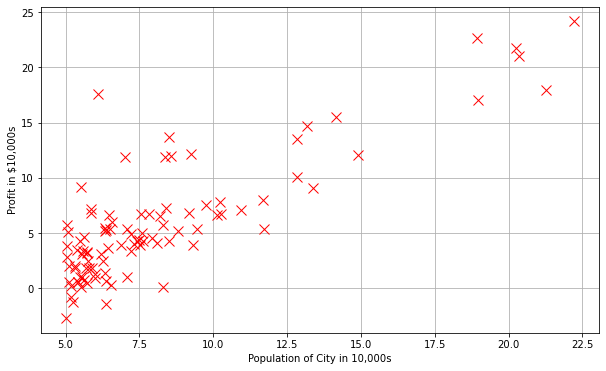

In [3]:
#Plot the data to see what it looks like
plt.figure(figsize=(10,6))
plt.plot(X[:,1],y[:,0],'rx',markersize=10)
plt.grid(True)
plt.ylabel('Profit in $10,000s')
plt.xlabel('Population of City in 10,000s')

### Gradient Descent

In [4]:
iterations = 1500
alpha = 0.01

In [5]:
def h(theta,X): #Linear hypothesis function
    return np.dot(X,theta)

def computeCost(mytheta,X,y): #Cost function
    return float((1./(2*m)) * np.dot((h(mytheta,X)-y).T,(h(mytheta,X)-y)))

initial_theta = np.zeros((X.shape[1],1)) #(theta is a vector with n rows and 1 columns)
print(computeCost(initial_theta,X,y))

32.07273387745567


In [6]:
#Gradient descent minimize
def descendGradient(X, theta_start = np.zeros(2)):
    theta = theta_start
    jvec = []
    thetaHistory = []
    for meaninglessvariable in range(iterations):
        temptheta = theta
        jvec.append(computeCost(theta, X, y))
        thetaHistory.append(list(theta[:,0]))
        
        for j in range(len(temptheta)):
            temptheta[j] = theta[j] - (alpha/m) * np.sum((h(initial_theta, X) - y) * np.array(X[:,j]).reshape(m, 1))
        theta = temptheta
    return theta, thetaHistory, jvec

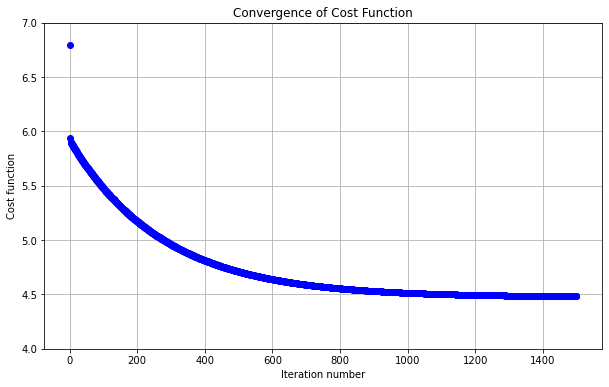

In [7]:
initial_theta = np.zeros((X.shape[1],1))
theta, thetahistory, jvec = descendGradient(X,initial_theta)

def plotConvergence(jvec):
    plt.figure(figsize=(10,6))
    plt.plot(range(len(jvec)),jvec,'bo')
    plt.grid(True)
    plt.title("Convergence of Cost Function")
    plt.xlabel("Iteration number")
    plt.ylabel("Cost function")
    dummy = plt.xlim([-0.05*iterations,1.05*iterations])
    
plotConvergence(jvec)
dummy = plt.ylim([4,7])

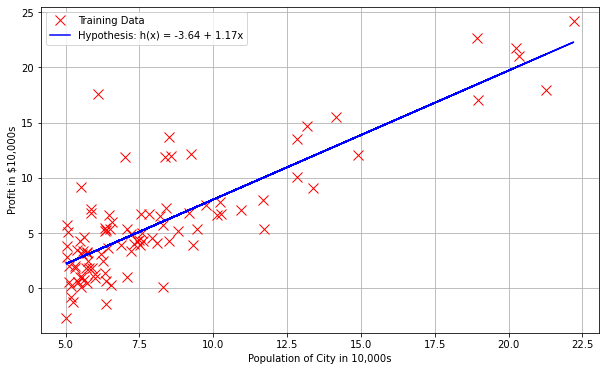

In [8]:
#Plot the line on top of the data to ensure it looks correct
def myfit(xval):
    return theta[0] + theta[1]*xval
plt.figure(figsize=(10,6))
plt.plot(X[:,1],y[:,0],'rx',markersize=10,label='Training Data')
plt.plot(X[:,1],myfit(X[:,1]),'b-',label = 'Hypothesis: h(x) = %0.2f + %0.2fx'%(theta[0],theta[1]))
plt.grid(True)
plt.ylabel('Profit in $10,000s')
plt.xlabel('Population of City in 10,000s')
plt.legend()

## Multiple Features

In [9]:
datafile = 'data/ex1data2.txt'

cols = np.loadtxt(datafile,delimiter=',',usecols=(0,1,2),unpack=True) 
#Read in comma separated data

#Form the usual "X" matrix and "y" vector
X = np.transpose(np.array(cols[:-1]))
y = np.transpose(np.array(cols[-1:]))
m = y.size
#Insert the usual column of 1's into the "X" matrix
X = np.insert(X,0,1,axis=1)

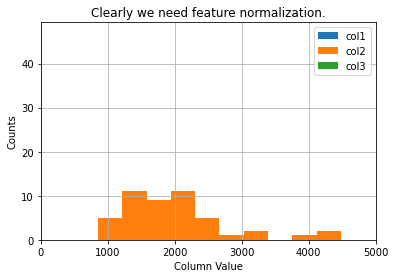

In [10]:
#Quick visualize data
plt.grid(True)
plt.xlim([0,5000])
dummy = plt.hist(X[:,0],label = 'col1')
dummy = plt.hist(X[:,1],label = 'col2')
dummy = plt.hist(X[:,2],label = 'col3')
plt.title('Clearly we need feature normalization.')
plt.xlabel('Column Value')
plt.ylabel('Counts')
dummy = plt.legend()

In [11]:
#Feature normalizing the columns (subtract mean, divide by standard deviation)
#Note don't modify the original X matrix, use a copy

stored_feature_means, stored_feature_stds = [], []
Xnorm = X.copy()
for icol in range(Xnorm.shape[1]):
    stored_feature_means.append(np.mean(Xnorm[:,icol]))
    stored_feature_stds.append(np.std(Xnorm[:,icol]))
    #Skip the first column
    if not icol: continue
    Xnorm[:,icol] = (Xnorm[:,icol] - stored_feature_means[-1])/stored_feature_stds[-1]

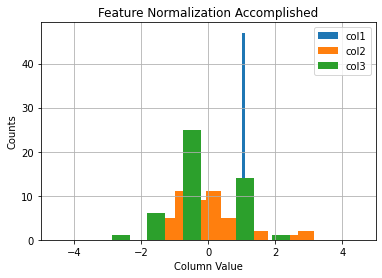

In [12]:
#Quick visualize the feature-normalized data
plt.grid(True)
plt.xlim([-5,5])
dummy = plt.hist(Xnorm[:,0],label = 'col1')
dummy = plt.hist(Xnorm[:,1],label = 'col2')
dummy = plt.hist(Xnorm[:,2],label = 'col3')
plt.title('Feature Normalization Accomplished')
plt.xlabel('Column Value')
plt.ylabel('Counts')
dummy = plt.legend()

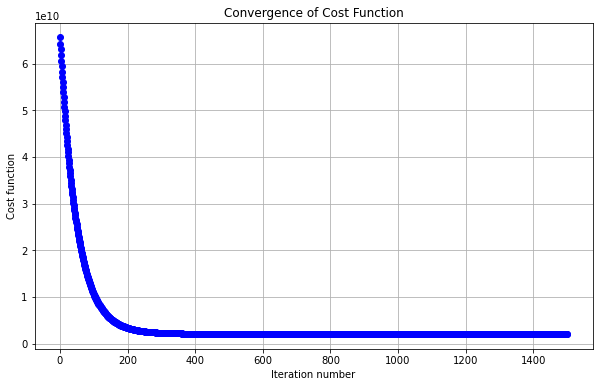

In [13]:
#Run gradient descent with multiple variables, initial theta still set to zeros
initial_theta = np.zeros((Xnorm.shape[1],1))
theta, thetahistory, jvec = descendGradient(Xnorm,initial_theta)

#Plot convergence of cost function:
plotConvergence(jvec)

In [14]:
print("Check of result: What is price of house with 1650 square feet and 3 bedrooms?")
ytest = np.array([1650.,3.])
ytestscaled = [(ytest[x]-stored_feature_means[x+1])/stored_feature_stds[x+1] for x in range(len(ytest))]
ytestscaled.insert(0,1)
print("$%0.2f" % float(h(theta,ytestscaled)))

Check of result: What is price of house with 1650 square feet and 3 bedrooms?
$293098.15


### Normal equation 

In [15]:
from numpy.linalg import inv
def normEqtn(X,y):
    #restheta = np.zeros((X.shape[1],1))
    return np.dot(np.dot(inv(np.dot(X.T,X)),X.T),y)

print("Normal equation prediction for price of house with 1650 square feet and 3 bedrooms")
print("$%0.2f" % float(h(normEqtn(X,y),[1,1650.,3])))

Normal equation prediction for price of house with 1650 square feet and 3 bedrooms
$293081.46
